# EDA: Avisos de venta en CABA

Objetivo: entender la distribucion de precios y su estructura espacial usando el dataset ya procesado para modelado.

Este notebook hace:

1. Carga del CSV procesado (`arg_venta_caba_processed.csv`) y reconstruccion del `GeoDataFrame`.
2. Limpiezas que aprenden del dataset y se dejan en notebook.
3. Exploracion espacial del **precio por m2** (kriging exploratorio).
4. Deteccion simple de valores atipicos en `precio_sobre_m2`.


In [1]:
import sys, os
from pathlib import Path
PROJECT_ROOT = Path(os.path.abspath(".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import folium
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm
import ast
from shapely.ops import unary_union
from pykrige.uk import UniversalKriging
from esda import G_Local
import matplotlib.pyplot as plt
from libpysal.weights import Kernel
from datetime import datetime




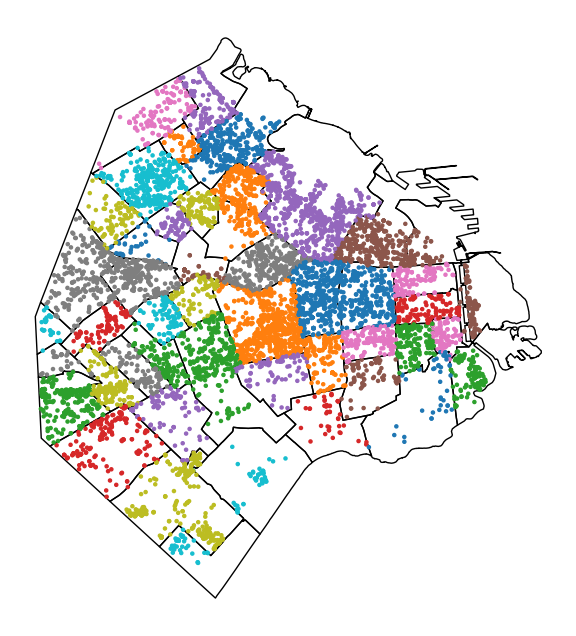

In [2]:
data_path = PROJECT_ROOT / 'scraper_service' / 'storage' / 'data' / 'arg_venta_caba_processed.csv'
barrios_path = PROJECT_ROOT / 'barrios.geojson'

df = pd.read_csv(data_path)
barrios = gpd.read_file(barrios_path)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitud, df.latitud),
    crs='EPSG:4326'
)

barrios = barrios.to_crs(gdf.crs)

fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor='black', facecolor='none')

gdf.plot(
    ax=ax,
    column='barrio',
    markersize=5,
    legend=False,
)

ax.set_axis_off()
plt.show()


In [3]:
# Limpiezas que aprenden del dataset y se mantienen en el notebook
min_obs_barrio = 5
gdf = gdf[gdf.groupby('barrio')['barrio'].transform('size') >= min_obs_barrio].copy()

gdf['antiguedad'] = gdf['antiguedad'].fillna(
    gdf.groupby('barrio')['antiguedad'].transform('mean')
)
gdf['antiguedad'] = gdf['antiguedad'].fillna(gdf['antiguedad'].median())

gdf['antiguedad_cat'] = gdf['antiguedad'].round().astype('Int64')

estado_moda = (
    gdf
    .dropna(subset=['estado'])
    .groupby(['barrio', 'antiguedad_cat'])['estado']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

mask_estado = gdf['estado'].isna()
gdf.loc[mask_estado, 'estado'] = (
    gdf.loc[mask_estado]
    .set_index(['barrio', 'antiguedad_cat'])
    .index
    .map(estado_moda)
)
gdf['estado'] = gdf['estado'].fillna(gdf['estado'].mode().iloc[0])

orden_estado = {
    'Excelente': 5,
    'Muy Bueno': 4,
    'Bueno': 3,
    'Regular': 2,
    'A Refaccionar': 1,
}
gdf['estado_num'] = gdf['estado'].map(orden_estado)


## Fuente de datos

Este notebook parte del CSV `scraper_service/storage/data/arg_venta_caba_processed.csv`, generado por `pipelines.preprocessing`.
Ese archivo ya trae la limpieza deterministica y la normalizacion de moneda/precio.
Aca quedan solo las limpiezas que aprenden del dataset antes del analisis.


In [4]:
gdf = gdf.reset_index(drop=True)


## Hipotesis

El precio de una propiedad depende de su superficie (en m2) y de la cantidad de ambientes. Sin embargo, la hipotesis es que **la relacion entre estas variables y el precio no es espacialmente homogenea**: los efectos marginales pueden variar segun el barrio/ubicacion.

Ejemplo: a igual superficie y ambientes, el premio por "estar en cierto barrio" y/o el impacto de sumar un ambiente podria ser distinto en Palermo que en Caballito.

### Decisiones de limpieza (para interpretar los graficos)

- Se filtran avisos no vigentes (`valido_hasta` nulo) y registros sin variables basicas (precio, area, ambientes).
- Se convierten precios en ARS a USD usando el dolar oficial (venta) del dia de scraping.
- Se aplican imputaciones simples para no perder demasiadas filas (expensas/banos/cocheras/area descubierta).

---

## Analisis

Para explorar esta hipotesis, se analiza la relacion entre el precio (USD) y la superficie (m2), estratificando por cantidad de ambientes y comparando patrones por barrio.


In [5]:
densidad_naive = (
    gdf
    .groupby('barrio')
    .size()
    .sort_values(ascending=False)
)

densidad_naive


barrio
Palermo              922
Caballito            685
Villa Urquiza        570
Almagro              516
Belgrano             368
Villa Crespo         350
Liniers              326
Recoleta             314
Villa Del Parque     297
Balvanera            294
Flores               293
Villa Luro           282
Villa Lugano         277
Villa Devoto         264
Colegiales           242
Nuñez                232
Mataderos            222
Constitucion         200
San Cristobal        195
Saavedra             186
Boedo                182
Villa Ortuzar        167
Monserrat            141
La Boca              140
San Nicolas          127
Villa Santa Rita     127
Floresta             122
Parque Avellaneda    121
Velez Sarsfield      119
Chacarita            118
Villa Pueyrredon     110
Puerto Madero        106
Monte Castro         100
San Telmo            100
Parque Chas           93
Coghlan               92
Parque Chacabuco      91
Paternal              89
Villa Gral. Mitre     86
Parque Patricios  

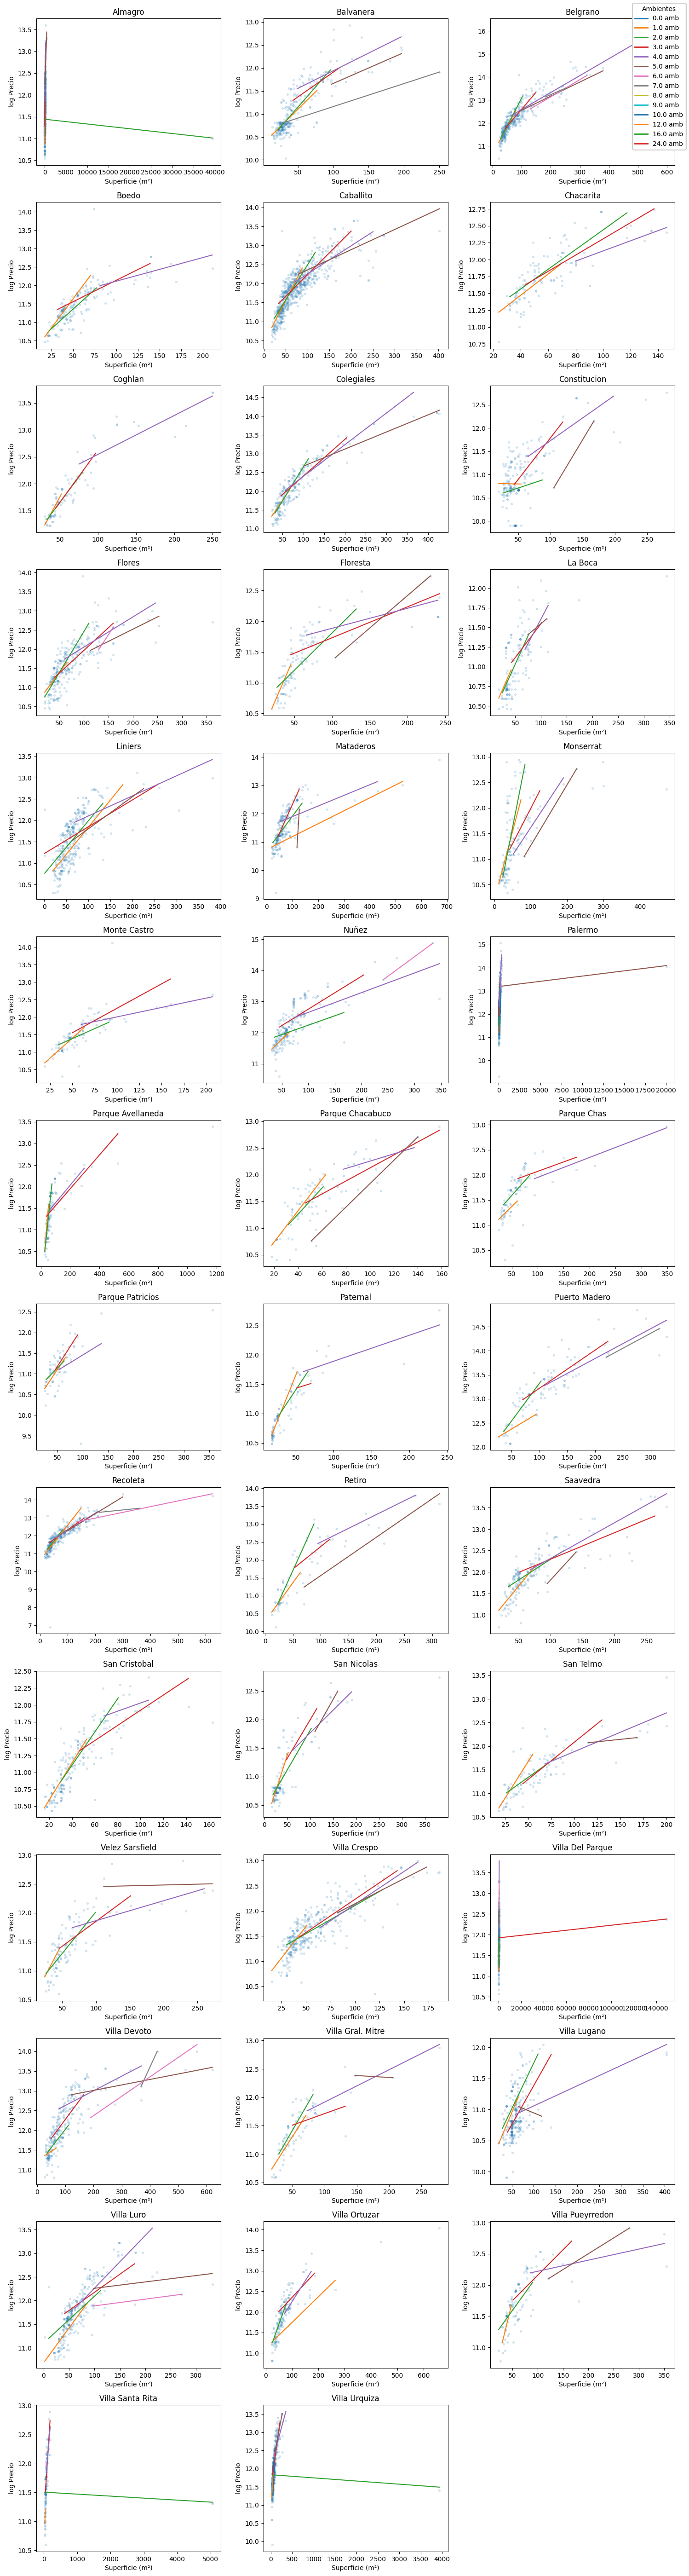

In [6]:
min_obs = 50

barrios_con_observaciones = (
    gdf
    .groupby('barrio')
    .size()
    .loc[lambda s: s >= min_obs]
    .index
    .tolist()
)

n = len(barrios_con_observaciones)
ncols = 3
nrows = int(np.ceil(n / ncols))

import matplotlib.cm as cm
from matplotlib.lines import Line2D

ambientes = sorted(gdf['ambientes'].unique())
cmap = cm.get_cmap("tab10")

color_por_amb = {
    amb: cmap(i % cmap.N)
    for i, amb in enumerate(ambientes)
}

# Límites globales
xmin = gdf['area_m2_total'].min()
xmax = 400

ymin = gdf['log_precio'].min()
ymax = 2*1e6


fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, barrio in zip(axes, barrios_con_observaciones):

    gdf_b = gdf[gdf['barrio'] == barrio]

    # ---- densidad de puntos ----
    ax.scatter(
        gdf_b['area_m2_total'],
        gdf_b['log_precio'],
        s=8,
        alpha=0.15
    )

    for amb in sorted(gdf_b['ambientes'].unique()):
        sub = gdf_b[gdf_b['ambientes'] == amb]

        X = sm.add_constant(sub['area_m2_total'])
        y = sub['log_precio']

        model = sm.OLS(y, X).fit()

        x_grid = np.linspace(
            sub['area_m2_total'].min(),
            sub['area_m2_total'].max(),
            100
        )

        y_hat = model.predict(
            sm.add_constant(x_grid)
        )

        ax.plot(
            x_grid,
            y_hat,
            color=color_por_amb[amb],
            label=f'{amb} amb'
        )



    ax.set_title(barrio)
    ax.set_xlabel('Superficie (m²)')
    ax.set_ylabel('log Precio')

    legend_elements = [
        Line2D(
            [0], [0],
            color=color_por_amb[amb],
            lw=2,
            label=f'{amb} amb'
        )
        for amb in ambientes
    ]

    fig.legend(
        handles=legend_elements,
        loc='upper right',
        title='Ambientes'
    )

for ax in axes[len(barrios_con_observaciones):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Analisis exploratorio espacial del precio por m2

Se calcula el **precio por metro cuadrado** como `precio / area_m2_total` y se aplica kriging para obtener una superficie espacial suave que ayude a visualizar, de forma exploratoria, la estructura espacial del precio en la ciudad.

Notas:

- Para el variograma/kriging se reproyectan las coordenadas a un CRS metrico (EPSG:3857) para trabajar en metros.
- El kriging aca es **exploratorio** (no es una validacion formal del modelo).

El mapa suele mostrar valores altos en la franja costera (por ejemplo, Puerto Madero) y un gradiente con precios menores hacia el sudoeste.


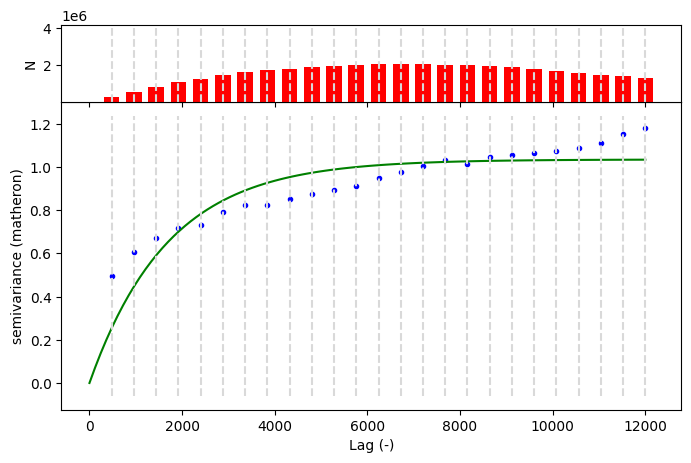

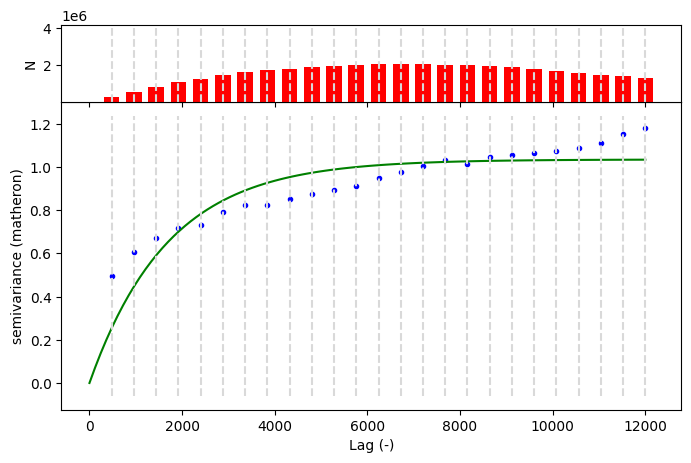

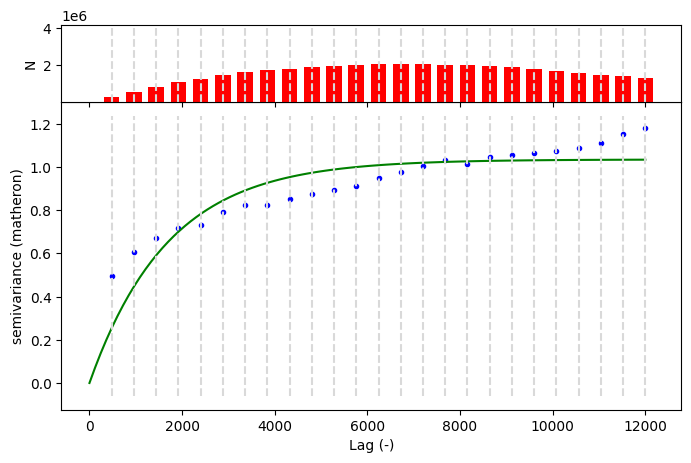

In [7]:
# Reproyeccion a CRS metrico para usar distancias (metros)
gdf_m = gdf.to_crs(epsg=3857)
barrios_m = gpd.read_file("../barrios.geojson").to_crs(gdf_m.crs)
caba_polygon = unary_union(barrios_m.geometry)

# Grilla para prediccion (mas chica para que el notebook sea liviano)
xmin, ymin, xmax, ymax = caba_polygon.bounds
grid_size = 300

xs = np.linspace(xmin, xmax, grid_size)
ys = np.linspace(ymin, ymax, grid_size)

xx, yy = np.meshgrid(xs, ys)
coords_grid = np.column_stack([xx.ravel(), yy.ravel()])

gdf_grid = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in coords_grid],
    crs=gdf_m.crs
)

gdf_grid = gdf_grid[gdf_grid.within(caba_polygon)]
coords_grid = np.array([(p.x, p.y) for p in gdf_grid.geometry])

# Target: precio por m2
precio_por_m2 = gdf_m["precio"] / gdf_m["area_m2_total"]

mask = (
    np.isfinite(precio_por_m2) &
    (gdf_m["area_m2_total"] >= 15)
)

# Coordenadas y variable (en metros)
x = gdf_m.geometry.x.values[mask]
y = gdf_m.geometry.y.values[mask]
v = precio_por_m2.values[mask]

coords = np.column_stack([x, y])

# Si hay coords duplicadas exactas, el variograma/kriging pueden fallar.
# Jitter minimo en metros solo para esas filas (reproducible).
np.random.seed(42)
_, uniq_counts = np.unique(coords, axis=0, return_counts=True)
if (uniq_counts > 1).any():
    # identificamos duplicados de forma simple por hashing
    import pandas as _pd
    _dfc = _pd.DataFrame(coords, columns=["x", "y"])
    dup_mask = _dfc.duplicated(subset=["x", "y"], keep=False).to_numpy()
    coords[dup_mask, 0] += np.random.normal(0, 1.0, size=dup_mask.sum())
    coords[dup_mask, 1] += np.random.normal(0, 1.0, size=dup_mask.sum())
    x = coords[:, 0]
    y = coords[:, 1]

V = Variogram(
    coords,
    v,
    model="exponential",
    n_lags=25,
    maxlag=12000
)

range_ = V.parameters[0]
sill = V.parameters[1]
nugget = V.parameters[2]

V.plot()


In [8]:
# Kriging en CRS metrico (x/y en metros)

""" Comentado por tardar mucho y dar malos resultados, pero queda como referencia de uso de pykrige con drift lineal regional (tendencia espacial)

UK = UniversalKriging(
    x,
    y,
    v,
    variogram_model="spherical",
    variogram_parameters={
        "range": range_,
        "sill": sill,
        "nugget": nugget
    },
    drift_terms=["regional_linear"]
)


z, ss = UK.execute(
    'points',
    coords_grid[:, 0],
    coords_grid[:, 1]
)
z = np.ma.filled(z, np.nan)

gdf_grid['precio_m2_ok'] = z

fig, ax = plt.subplots(figsize=(10, 10))

sc = ax.scatter(
    gdf_grid.geometry.x,
    gdf_grid.geometry.y,
    c=gdf_grid['precio_m2_ok'],
    s=15,
)

barrios_m.boundary.plot(ax=ax, color='black', linewidth=0.8)

plt.colorbar(sc, ax=ax, label='Precio por m² (OK)')
ax.set_title('Precio por m² – Ordinary Kriging')
ax.set_axis_off()
plt.show() """


' Comentado por tardar mucho y dar malos resultados, pero queda como referencia de uso de pykrige con drift lineal regional (tendencia espacial)\n\nUK = UniversalKriging(\n    x,\n    y,\n    v,\n    variogram_model="spherical",\n    variogram_parameters={\n        "range": range_,\n        "sill": sill,\n        "nugget": nugget\n    },\n    drift_terms=["regional_linear"]\n)\n\n\nz, ss = UK.execute(\n    \'points\',\n    coords_grid[:, 0],\n    coords_grid[:, 1]\n)\nz = np.ma.filled(z, np.nan)\n\ngdf_grid[\'precio_m2_ok\'] = z\n\nfig, ax = plt.subplots(figsize=(10, 10))\n\nsc = ax.scatter(\n    gdf_grid.geometry.x,\n    gdf_grid.geometry.y,\n    c=gdf_grid[\'precio_m2_ok\'],\n    s=15,\n)\n\nbarrios_m.boundary.plot(ax=ax, color=\'black\', linewidth=0.8)\n\nplt.colorbar(sc, ax=ax, label=\'Precio por m² (OK)\')\nax.set_title(\'Precio por m² – Ordinary Kriging\')\nax.set_axis_off()\nplt.show() '

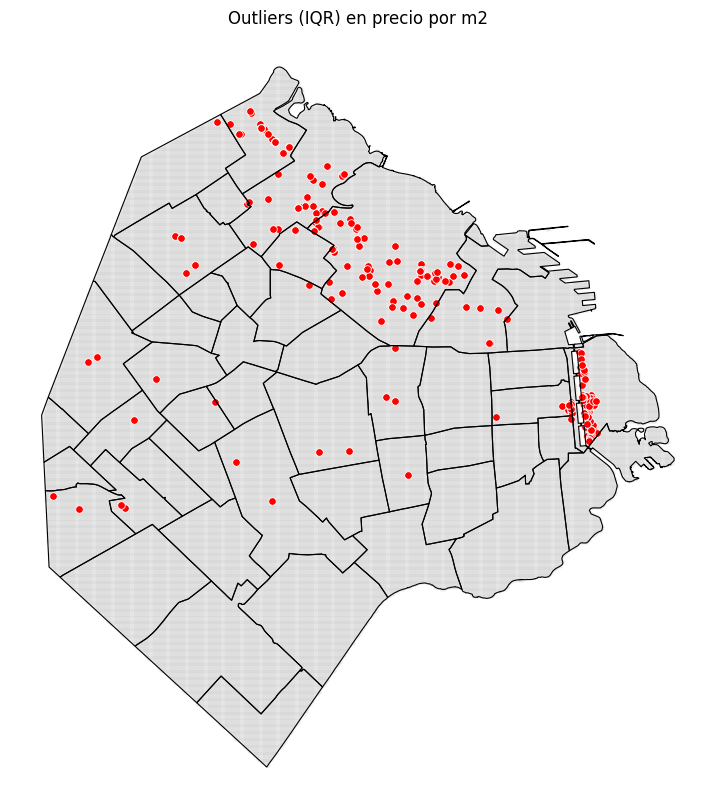

In [9]:
gdf = gdf.copy()

# Precio por m2
gdf["precio_sobre_m2"] = gdf["precio"] / gdf["area_m2_total"]
gdf.loc[~np.isfinite(gdf["precio_sobre_m2"]), "precio_sobre_m2"] = np.nan

s = gdf["precio_sobre_m2"].dropna()

q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr

outliers_iqr = gdf[(gdf["precio_sobre_m2"] < lo) | (gdf["precio_sobre_m2"] > hi)]

lo_ext = q1 - 3 * iqr
hi_ext = q3 + 3 * iqr
outliers_super = gdf[(gdf["precio_sobre_m2"] < lo_ext) | (gdf["precio_sobre_m2"] > hi_ext)]

# Plot espacial: usar la geometria reproyectada para que coincida con el mapa
# (tomamos las mismas filas por indice)
gdf_m = gdf.to_crs(epsg=3857)
barrios_m = gpd.read_file("../barrios.geojson").to_crs(gdf_m.crs)

outliers_iqr_m = gdf_m.loc[outliers_iqr.index]  # conserva geometry en EPSG:3857

fig, ax = plt.subplots(figsize=(10, 10))

# Base: grilla (si existe de la seccion de kriging)
try:
    gdf_grid.plot(ax=ax, color="lightgray", alpha=0.25, markersize=5)
except Exception:
    pass

# Outliers
outliers_iqr_m.plot(ax=ax, color="red", markersize=30, edgecolor="white", linewidth=0.6)

barrios_m.boundary.plot(ax=ax, color="black", linewidth=0.8)

ax.set_title("Outliers (IQR) en precio por m2")
ax.set_axis_off()
plt.show()


## Limpieza: outliers extremos (regla 3?)

Eliminamos avisos con **precio por m?** extremadamente alto, definidos como aquellos que superan **media + 3?desv?o est?ndar**.


In [10]:
# Regla 3? (1 cola: outliers altos)

pm2 = gdf["precio_sobre_m2"].astype(float)
mu = pm2.mean(skipna=True)
sigma = pm2.std(skipna=True)  # ddof=1

if not (np.isfinite(mu) and np.isfinite(sigma)) or sigma <= 0:
    print("No se puede aplicar 3?: sigma inv?lido.")
    outliers_3sigma = gdf.iloc[0:0].copy()
else:
    upper_cut = mu + 3 * sigma
    mask_out = pm2 > upper_cut

    outliers_3sigma = gdf.loc[mask_out].copy()
    print(f"Corte 3? (upper): {upper_cut:,.2f}")
    print(f"Outliers 3? (altos): {mask_out.sum()} / {len(gdf)} ({mask_out.mean():.2%})")

    gdf = gdf.loc[~mask_out].copy().reset_index(drop=True)
    print(f"Filas luego de filtrar: {len(gdf)}")


Corte 3? (upper): 9,866.58
Outliers 3? (altos): 18 / 9697 (0.19%)
Filas luego de filtrar: 9679


In [11]:
# Mapa interactivo de outliers extremos (3 sigma)
import folium

# Centro aproximado de CABA
centro_caba = [-34.6118, -58.3965]

m = folium.Map(location=centro_caba, zoom_start=11)

# Agregar outliers como círculos rojos con popup
for idx, row in outliers_3sigma.iterrows():
    precio_m2 = row['precio_sobre_m2']
    url = row['url']
    lat, lon = row.geometry.y, row.geometry.x
    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        color='red',
        fill=True,
        fill_color='red',
        popup=f'<a href="{url}" target="_blank">Ver propiedad</a><br>Precio/m²: {precio_m2:,.2f} USD'
    ).add_to(m)

# Mostrar el mapa
m

El CSV procesado se genera fuera del notebook con:

`python -m pipelines.preprocessing.build_processed_data --dataset venta`


In [1]:
print(outliers_3sigma['barrio'].unique())

NameError: name 'outliers_3sigma' is not defined